In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import xarray as xr
import scipy.io as sio
from datetime import datetime, timedelta

import sys
sys.path.append("functions") 
from functions import latte, latte_source_selector, axis_ratio_from_Q, tangential_velocity, out_core_param_fit, model_uv_at_xy, vector_R2


### SADCP Data

In [2]:
sad = sio.loadmat('data/sadcp_data.mat', simplify_cells=True)

z = sad['z_sadcp']
ref = datetime(2000,1,1,12)
time = np.array([ref + timedelta(days=jd-2451545.0) for jd in sad['tim_sadcp']], dtype='datetime64[ns]')

df = pd.DataFrame({
    "Time": time,
    "Lon": sad['lon_sadcp'],
    "Lat": sad['lat_sadcp']
})

df = pd.concat([
    df,
    pd.DataFrame(sad['u_sadcp'], index=[f'u_{zv}' for zv in z]).T,
    pd.DataFrame(sad['v_sadcp'], index=[f'v_{zv}' for zv in z]).T
], axis=1)

df = df[df.Lat <= -37].reset_index(drop=True)

theta_mean, phi_mean = 154.3, -37.9
df["x"] = (df.Lon-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
df["y"] = (df.Lat-phi_mean)*111000

ds_sadcp = xr.Dataset(
    {"u": (("time","z"), df[[f"u_{zz}" for zz in z]].to_numpy()),
     "v": (("time","z"), df[[f"v_{zz}" for zz in z]].to_numpy())},
    coords={
        "time": df.Time.values,
        "z": z,
        "lon": ("time", df.Lon.values),
        "lat": ("time", df.Lat.values),
        "x": ("time", df.x.values),
        "y": ("time", df.y.values),
    }
)

ds_sadcp


<xarray.Dataset> Size: 565kB
Dimensions:  (time: 433, z: 79)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-10-17T10:27:31.000004 ... 2023-10...
  * z        (z) uint16 158B 27 37 47 57 67 77 87 ... 757 767 777 787 797 807
    lon      (time) float64 3kB 154.4 154.4 154.4 154.4 ... 154.2 154.2 154.2
    lat      (time) float64 3kB -37.01 -37.04 -37.07 ... -37.09 -37.06 -37.03
    x        (time) float64 3kB 4.998e+03 5.326e+03 ... -1.057e+04 -1.057e+04
    y        (time) float64 3kB 9.932e+04 9.567e+04 ... 9.343e+04 9.673e+04
Data variables:
    u        (time, z) float64 274kB nan 0.5344 0.569 0.5493 ... nan nan nan nan
    v        (time, z) float64 274kB nan -0.05262 0.006571 ... nan nan nan

### Satellite Data

In [3]:
ssh_path = 'data/satellite_data.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)

# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)

# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))

ds_sat


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 101, lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time       (time) datetime64[ns] 808B 2023-10-19T06:00:00 ... 2024-01-27T...
Data variables:
    u          (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.2664 0.3238
    v          (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.4036 -0.314
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

### Calculate ESP parameters from selected data

,source,xc,yc,w,Q,Omega,Rc,psi0,time,alpha
0,multi,-372.710283,-429.926759,-0.000041,"[[1.1445551540946677, -0.04665524335735116], [...",-0.000020,75275.588296,57008.984343,2023-10-19 16:27:30.509622172,1.152419
1,sadcp,-630.462766,-698.395388,-0.000042,"[[1.1304059939390503, -0.052566977646175274], ...",-0.000021,72519.902962,55298.606919,2023-10-19 16:27:30.509622172,1.141277
2,sat,3933.888475,5432.439575,-0.000033,"[[1.2364155209261036, 0.03289181268616171], [0...",-0.000016,89539.876735,63674.622806,2023-10-19 16:27:30.509622172,1.238936


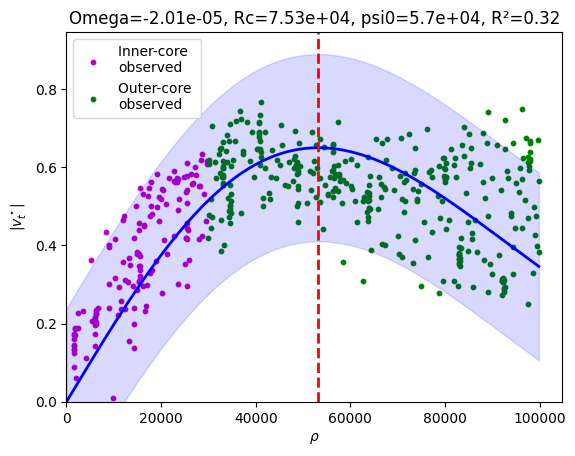

In [4]:
data_multi, df_xyuv_multi, df_rho_multi = latte_source_selector(ds_sadcp, ds_sat, source="multi", plot=True)
data_sadcp, df_xyuv_sadcp, df_rho_sadcp = latte_source_selector(ds_sadcp, ds_sat, source="sadcp", plot=False)
data_sat, df_xyuv_sat, df_rho_sat = latte_source_selector(ds_sadcp, ds_sat, source="sat", plot=False)

df_xyuv = pd.concat([df_xyuv_multi, df_xyuv_sadcp, df_xyuv_sat], ignore_index=True)
df_res = pd.concat([data_multi, data_sadcp, data_sat], ignore_index=True)
df_res


In [5]:
# Find R2
R2_vals = []
for (row, source) in zip([data_multi, data_sadcp, data_sat], ["multi", "sadcp", "sat"]):
    
    row = row.iloc[0]
    df = df_xyuv[df_xyuv.source == source]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))

df_res['R2'] = R2_vals
df_res


,source,xc,yc,w,Q,Omega,Rc,psi0,time,alpha,R2
0,multi,-372.710283,-429.926759,-0.000041,"[[1.1445551540946677, -0.04665524335735116], [...",-0.000020,75275.588296,57008.984343,2023-10-19 16:27:30.509622172,1.152419,0.907559
1,sadcp,-630.462766,-698.395388,-0.000042,"[[1.1304059939390503, -0.052566977646175274], ...",-0.000021,72519.902962,55298.606919,2023-10-19 16:27:30.509622172,1.141277,0.899772
2,sat,3933.888475,5432.439575,-0.000033,"[[1.2364155209261036, 0.03289181268616171], [0...",-0.000016,89539.876735,63674.622806,2023-10-19 16:27:30.509622172,1.238936,0.967839


In [6]:
# Reconstruct velocity field using ESP parameters
sources = ["multi", "sadcp", "sat"]

U_all = []
V_all = []

X = ds_sat.x.values
Y = ds_sat.y.values
mask = ds_sat.land_mask.values

for s in sources:
    data = df_res[df_res.source == s].iloc[0]

    dx = X - data.xc
    dy = Y - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U = -fac * (q12*dx + q22*dy)
    V =  fac * (q11*dx + q12*dy)

    U = np.where(mask, np.nan, U)
    V = np.where(mask, np.nan, V)

    U_all.append(U)
    V_all.append(V)

U_all = np.stack(U_all)
V_all = np.stack(V_all)

t = np.array([np.datetime64(df_res.time.iloc[0])])

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("source","time","lat","lon"), U_all[:,None,:,:]),
        v=(("source","time","lat","lon"), V_all[:,None,:,:]),
    ),
    coords=dict(
        source=sources,
        time=t,
        lat=ds_sat.lat.values,
        lon=ds_sat.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
        land_mask=(("lat","lon"), mask),
    ),
)
ds_model


<xarray.Dataset> Size: 123kB
Dimensions:    (source: 3, time: 1, lat: 41, lon: 46)
Coordinates:
  * source     (source) <U5 60B 'multi' 'sadcp' 'sat'
  * time       (time) datetime64[us] 8B 2023-10-19T16:27:30.509622
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
    land_mask  (lat, lon) bool 2kB False False False False ... False False False
Data variables:
    u          (source, time, lat, lon) float64 45kB -4.372e-31 ... 2.437e-15
    v          (source, time, lat, lon) float64 45kB 5.919e-31 ... -2.801e-15

In [7]:
def plot_model(source, df_res, ds_sat, ds_model, df_xyuv, spac=1, scale=20,
                      xlim=(-170, 170), ylim=(-170, 170), out_thresh=False, plot_data=False):

    data = df_res[df_res.source == source].iloc[0]
    time = data.time

    sat = ds_sat.sel(time=time, method="nearest")
    mod = ds_model.sel(source=source).sel(time=time, method="nearest")#.squeeze("time")

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    levels = np.arange(0, vmax+.05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100), np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    fig, axs = plt.subplots(1, 3, figsize=(16,5), constrained_layout=True) #sharex=True, sharey=True

    # Satellite
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")
    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, alpha=.4, width=.0015)
    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[((data.Rc)**2)/2], colors="r", linewidths=2, linestyles="--")
    dsrc = df_res[df_res.source == source]
    axs[0].plot(dsrc.xc/1e3, dsrc.yc/1e3, color="r", lw=.5)
    if plot_data:
        df = df_xyuv.copy()
        df = df_xyuv[(df_xyuv.source==source)&(df_xyuv.core=='outer')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='g', label='Outer-core data')
        df = df_xyuv[(df_xyuv.source==source)&(df_xyuv.core=='inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='m', label='Inner-core data')
    # axs[0].set_title("Satellite");
    axs[0].set_aspect("equal"); axs[0].legend(loc='lower right')

    # Model
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center')
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles="--")
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity', ls='--')
    # axs[1].set_title("Model - LATTE with S-ADCP and Satellite Data")
    axs[1].set_aspect("equal"); axs[1].legend(loc='lower right')

    gap = 20
    for ax in [axs[0], axs[1]]:
        # ax.axis('equal')
        ax.set_xlim(xlim[0]+gap, xlim[1]-gap)
        ax.set_ylim(ylim[0]+gap, ylim[1]-gap)
        ax.set_xlabel("x (km)")
        
        ax.set_ylabel("y (km)")

    axs[0].text(-0.1, 1.07, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.1, 1.07, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    fig.colorbar(h1, ax=axs[1], label=r"Current speed (ms$^{-1}$)", fraction=0.05, pad=0.02)

    out_core_param_fit(df_xyuv.xi/1e3, df_xyuv.yi/1e3, df_xyuv.ui, df_xyuv.vi, data.xc/1e3, data.yc/1e3, data.Q, Omega0=data.Omega, ax=axs[2],
                       plot=True, km_flag=True, pred_flag=True)
    axs[2].set_title('')
    axs[2].set_xlabel(r'$\rho$ (km)')
    axs[2].set_ylabel(r'Normalised tangential velocity (ms$^{-1}$)')
    axs[2].text(-0.1, 1.07, "c)", transform=axs[2].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[2].get_legend().remove()
    
    plt.show()
    

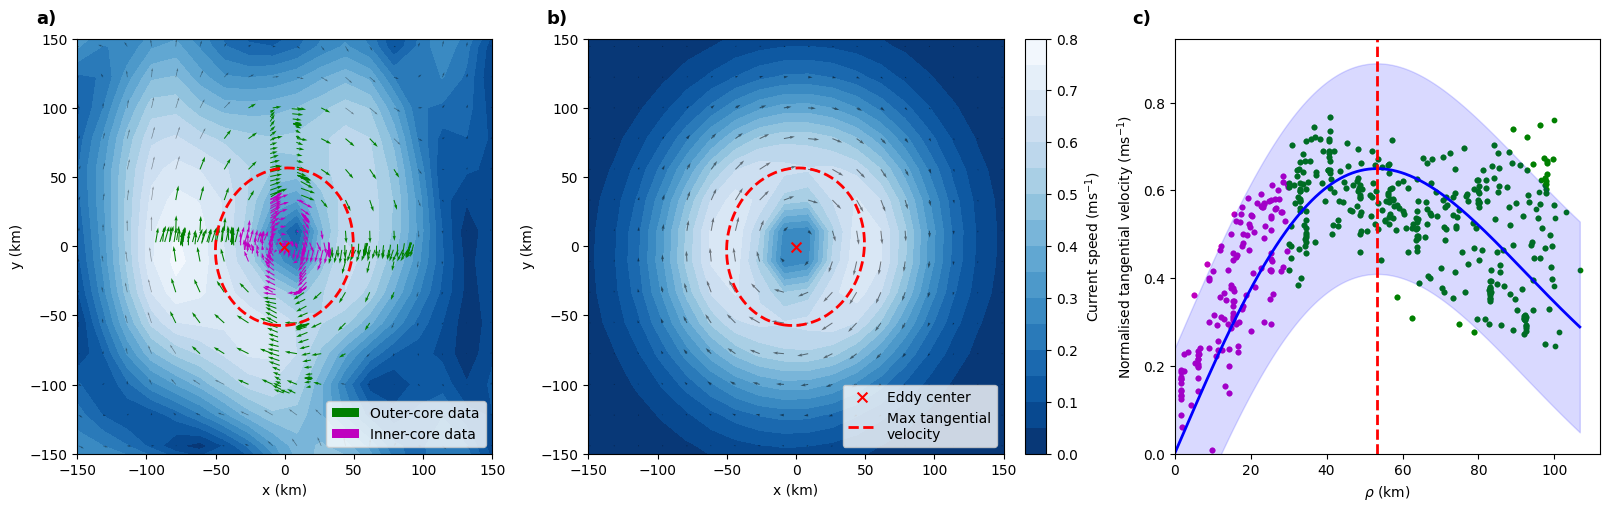

In [8]:
plot_model('multi', df_res, ds_sat, ds_model, df_xyuv, plot_data=True)


In [9]:
# Results
df_paper = df_res.copy()
df_paper = df_paper.drop(columns='Q')
df_paper


,source,xc,yc,w,Omega,Rc,psi0,time,alpha,R2
0,multi,-372.710283,-429.926759,-0.000041,-0.000020,75275.588296,57008.984343,2023-10-19 16:27:30.509622172,1.152419,0.907559
1,sadcp,-630.462766,-698.395388,-0.000042,-0.000021,72519.902962,55298.606919,2023-10-19 16:27:30.509622172,1.141277,0.899772
2,sat,3933.888475,5432.439575,-0.000033,-0.000016,89539.876735,63674.622806,2023-10-19 16:27:30.509622172,1.238936,0.967839
